# Approximate segmentation through tile prediction

Identifying tissue structures in histopathology images is typically challenging due to sparse annotations required to train segmentation models. However, we can approximate the segmentation problem by transforming it into a tile prediction task on small image patches. This approach allows us to leverage the power of foundation models to train effective tile prediction models with minimal annotations. An additional benefit is that training such models can be accomplished easily without requiring a GPU.

This tutorial demonstrates how to use LazySlide and wsidata to construct a tile prediction model based on extracted tile features.

## Dataset

For this tutorial, we'll use GTEx Stomach slides with pre-existing annotations. You can create annotations using [QuPath](https://qupath.github.io/) or other annotation tools and import them into wsidata as a GeoDataFrame. These annotations can then be used to label the tiles.

Here's an example workflow:

```python
from wsidata import open_wsi
import lazyslide as zs

slide_path = "my_wsi.svs"
annotations = "anno.geojson"  # Annotation exported from QuPath

wsi = open_wsi(slide_path)  # Open the WSI
zs.pp.find_tissues(wsi)
zs.pp.tile_tissues(wsi, 128)

zs.io.load_annotations(wsi, annotations)  # Load annotations into wsidata

# Use spatial join to label tiles - adjust code based on your table content
wsi['tiles'] = wsi['tiles'].sjoin(wsi['annotations'])
```

For this tutorial, we've prepared an example dataset containing slides for training and evaluation, plus additional slides for inference testing. This ensures that our model can demonstrate real generalization capabilities.

In [1]:
from pathlib import Path
import zipfile

from huggingface_hub import hf_hub_download

zip_path = hf_hub_download(
    "RendeiroLab/LazySlide-data",
    "gtex_stomach_subset.zip",
    repo_type="dataset",
)

extract_dir = Path("datasets")

if not (extract_dir / "gtex-stomach-subset").exists():
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)

Let's explore the dataset structure:

In [2]:
from rich.console import Console
from rich.tree import Tree


def make_tree(path: Path, tree: Tree, level: int = 0, max_depth: int = None):
    """Recursively build tree from directory structure with depth control."""
    if max_depth is not None and level >= max_depth:
        return
    for p in sorted(path.iterdir()):
        if p.is_dir():
            branch = tree.add(f"[bold blue]{p.name}/[/]")
            make_tree(p, branch, level + 1, max_depth)
        else:
            tree.add(p.name)


def show_folder_tree(root_dir: str, max_depth: int = None):
    console = Console()
    root_path = Path(root_dir)
    tree = Tree(f"[bold magenta]{root_path.name}/[/]")
    make_tree(root_path, tree, level=0, max_depth=max_depth)
    console.print(tree)


show_folder_tree("datasets/gtex-stomach-subset", max_depth=2)

gtex-stomach-subset/
├── test/
│   ├── GTEX-1JJE9-2026.svs
│   ├── GTEX-1JJE9-2026.zarr/
│   ├── GTEX-Y111-2526.svs
│   └── GTEX-Y111-2526.zarr/
└── train/
    ├── GTEX-111FC-2126.zarr/
    ├── GTEX-11GS4-1626.zarr/
    ├── GTEX-11PRG-1826.zarr/
    ├── GTEX-11WQK-2626.zarr/
    ├── GTEX-11ZTT-1926.zarr/
    ├── GTEX-11ZVC-1926.zarr/
    ├── GTEX-12WSI-1326.zarr/
    ├── GTEX-12ZZW-2226.zarr/
    ├── GTEX-13111-1226.zarr/
    ├── GTEX-1339X-1426.zarr/
    ├── GTEX-139YR-1926.zarr/
    ├── GTEX-13CZV-2426.zarr/
    ├── GTEX-13N1W-2026.zarr/
    ├── GTEX-13NYB-1426.zarr/
    ├── GTEX-13NZ9-2326.zarr/
    ├── GTEX-13OVL-2826.zarr/
    ├── GTEX-13SLX-2026.zarr/
    ├── GTEX-13W3W-1926.zarr/
    ├── GTEX-14A6H-1626.zarr/
    ├── GTEX-14BIL-1926.zarr/
    ├── GTEX-14BIM-1526.zarr/
    ├── GTEX-14C5O-2426.zarr/
    ├── GTEX-14E6E-0926.zarr/
    ├── GTEX-14PJ3-1426.zarr/
    ├── GTEX-15FZZ-1426.zarr/
    ├── GTEX-15TU5-2526.zarr/
    ├── GTEX-17MF6-2126.zarr/
    ├── GTEX-18D9A-0626.zarr/
    ├── GTEX-1A3MV-1226.zarr/
    ├── GTEX-1A3MW-2326.zarr/
    ├── GTEX-1A3MX-1926.zarr/
    ├── GTEX-1AYCT-1326.zarr/
    ├── GTEX-1C6WA-1726.zarr/
    ├── GTEX-1CB4F-1626.zarr/
    ├── GTEX-1EH9U-2226.zarr/
    ├── GTEX-1EX96-2426.zarr/
    ├── GTEX-1F75W-2826.zarr/
    ├── GTEX-1HFI7-1526.zarr/
    ├── GTEX-1HSGN-2026.zarr/
    ├── GTEX-1I19N-2526.zarr/
    ├── GTEX-1IKJJ-2626.zarr/
    ├── GTEX-1J1OQ-2626.zarr/
    ├── GTEX-1JKYR-1526.zarr/
    ├── GTEX-1JMPY-0926.zarr/
    ├── GTEX-1MCC2-1726.zarr/
    ├── GTEX-1N2EE-2626.zarr/
    ├── GTEX-1O97I-1926.zarr/
    ├── GTEX-1OJC4-1926.zarr/
    ├── GTEX-1S83E-1126.zarr/
    ├── GTEX-O5YU-1926.zarr/
    ├── GTEX-OHPM-1526.zarr/
    ├── GTEX-OHPN-2126.zarr/
    ├── GTEX-P4QR-1926.zarr/
    ├── GTEX-PWO3-1926.zarr/
    ├── GTEX-R3RS-1926.zarr/
    ├── GTEX-RN64-1926.zarr/
    ├── GTEX-RWS6-0926.zarr/
    ├── GTEX-UPJH-2426.zarr/
    ├── GTEX-XBED-1226.zarr/
    ├── GTEX-XMK1-1526.zarr/
    ├── GTEX-XUZC-0726.zarr/
    ├── GTEX-ZF3C-2426.zarr/
    ├── GTEX-ZU9S-2526.zarr/
    ├── GTEX-ZXG5-2626.zarr/
    └── GTEX-ZYT6-1826.zarr/

All zarr files contain wsidata with features extracted using `virchow2` and an annotation column named `domain` in the tile table.

To train your own model, you'll need to prepare two key components:
- **Feature extraction**: Run feature extraction on all slides
- **Tile annotations**: Prior annotations on the tiles

wsidata provides a `FeaturesDatasetBuilder` that handles all the complex work during dataset preparation, including data balancing and data splitting.

In [3]:
from wsidata.dataset import FeaturesDatasetBuilder

stores = sorted(list((extract_dir / "gtex-stomach-subset" / "train").glob("*.zarr")))

builder = FeaturesDatasetBuilder(
    stores,
    tile_key="tiles",
    feature_key="virchow2",
    target_key="domain",
    skip_class=["artifact"],
    sampler="undersample",
    in_memory=True,  # Set to False if your dataset cannot fit into RAM, IterableDataset will be used instead
    seed=0,
)

/home/runner/work/lazyslide-tutorials/lazyslide-tutorials/.venv/lib/python3.12/site-packages/wsidata/dataset/multislides/builder.py:122: UserWarning: It looks like the target column contains NaN values. The NaN rows will be removed.
  warnings.warn(


Now let's split the dataset into training, validation, and test sets:

In [4]:
ds = builder.split(val=0.2, test=0.1)
ds

{'train': <wsidata.dataset.multislides.dataset.CachedFeaturesDataset at 0x7f281811dc40>,
 'test': <wsidata.dataset.multislides.dataset.CachedFeaturesDataset at 0x7f2800805430>,
 'val': <wsidata.dataset.multislides.dataset.CachedFeaturesDataset at 0x7f27f897a360>}

With our dataset prepared, we can begin model training. Since everyone has their own preferences for training approaches, we'll demonstrate an easy method using the Lightning framework.

For this showcase, we'll define a simple 2-layer network. In real-world applications, you may want to consider more complex network architectures.

Since we're tackling a multiclass classification task, our setup includes:
- **Loss function**: Cross-entropy
- **Evaluation metrics**: Accuracy and F1 score
- **Optimizer**: AdamW

In [5]:
import torch
from torch import nn, utils
from torchmetrics import Accuracy, F1Score

torch.manual_seed(42)
torch.use_deterministic_algorithms(True)

in_dims = 2560  # Feature dimension of Virchow2
n_class = 5  # Number of classes in the dataset


class Classifier(nn.Module):
    def __init__(self, in_dims, n_class):
        super().__init__()
        self.fc1 = nn.Linear(in_dims, 64)
        self.fc2 = nn.Linear(64, n_class)
        self.activation = nn.ReLU()
        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.zeros_(self.fc1.bias)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.zeros_(self.fc2.bias)

    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.fc2(x)
        return x


model = Classifier(in_dims, n_class)

Let's wrap our dataset in DataLoaders. Since this is an in-memory dataset, **avoid using multiple workers** in the DataLoader:

If you set `in_memory=False` in the dataset builder, it will return an IterableDataset. In such case, please use multiple workers.

In [6]:
train_loader = utils.data.DataLoader(ds["train"], batch_size=2000)
val_loader = utils.data.DataLoader(ds["val"], batch_size=2000)
test_loader = utils.data.DataLoader(ds["test"], batch_size=2000)

Next, we'll set up the blocks for model training:

In [7]:
loss = nn.CrossEntropyLoss()  # Loss function for multiclass classification
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
acc = Accuracy(task="multiclass", num_classes=n_class, average=None)
f1 = F1Score(task="multiclass", num_classes=n_class, average=None)
CLASSES = list(ds["train"].targets_mapping.keys())

Model training

In [8]:
for epoch in range(10):  # Loop over the dataset multiple times
    model.train()
    for i, batch in enumerate(train_loader):
        pred = model(batch["feature"])
        y = batch["target"]
        optimizer.zero_grad()  # Zero the parameter gradients
        train_loss = loss(pred, y)  # Compute loss
        train_loss.backward()  # Backward pass
        optimizer.step()  # Optimize the weights

Model validation

In [9]:
model.eval()
with torch.inference_mode():
    for i, batch in enumerate(val_loader):
        acc.reset()
        f1.reset()
        pred = model(batch["feature"])
        y = batch["target"]
        acc(pred, y)
        f1(pred, y)

    per_class_acc = acc.compute()
    per_class_f1 = f1.compute()

    print(f"Validation set at epoch={epoch}:")
    print(f"Overall Accuracy: {per_class_acc.mean():.4f}")
    for i, (class_name, class_acc) in enumerate(zip(CLASSES, per_class_acc)):
        print(f"  {class_name}: {class_acc:.4f}")

    print(f"Overall F1: {per_class_f1.mean():.4f}")
    for i, (class_name, class_f1) in enumerate(zip(CLASSES, per_class_f1)):
        print(f"  {class_name}: {class_f1:.4f}")

    acc.reset()
    f1.reset()

Validation set at epoch=9:
Overall Accuracy: 0.7923
  gastric foveolae: 0.6856
  gastric glands: 0.8694
  hemorrhage: 0.7206
  muscularis: 0.7882
  submucosa: 0.8977
Overall F1: 0.7934
  gastric foveolae: 0.7373
  gastric glands: 0.8606
  hemorrhage: 0.8203
  muscularis: 0.7243
  submucosa: 0.8243


Model testing

In [10]:
with torch.inference_mode():
    for i, batch in enumerate(test_loader):
        pred = model(batch["feature"])
        y = batch["target"]
        acc(pred, y)
        f1(pred, y)

    per_class_acc = acc.compute()
    per_class_f1 = f1.compute()

    print("Test set:")
    print(f"Overall Accuracy: {per_class_acc.mean():.4f}")
    for i, (class_name, class_acc) in enumerate(zip(CLASSES, per_class_acc)):
        print(f"  {class_name}: {class_acc:.4f}")

    print(f"Overall F1: {per_class_f1.mean():.4f}")
    for i, (class_name, class_f1) in enumerate(zip(CLASSES, per_class_f1)):
        print(f"  {class_name}: {class_f1:.4f}")

    acc.reset()
    f1.reset()

Test set:
Overall Accuracy: 0.7984
  gastric foveolae: 0.5929
  gastric glands: 0.9130
  hemorrhage: 0.8419
  muscularis: 0.8024
  submucosa: 0.8419
Overall F1: 0.7960
  gastric foveolae: 0.7026
  gastric glands: 0.8431
  hemorrhage: 0.8820
  muscularis: 0.7532
  submucosa: 0.7992


The model should train in just a few seconds. Here we achieved a test accuracy of >0.7, which is sufficient for inference demonstration.

**Tips to improve performance:**
- Increase training data volume
- Experiment with better network architectures
- Tune hyperparameters systematically
- Apply data augmentation techniques
- Use ensemble methods

Let's evaluate our model's performance visually using a slide that wasn't included in the training or evaluation sets.

Note: In this example dataset, feature extraction has already been completed for you.

In [11]:
from wsidata import open_wsi

test1 = open_wsi("datasets/gtex-stomach-subset/test/GTEX-1JJE9-2026.svs")

/home/runner/work/lazyslide-tutorials/lazyslide-tutorials/.venv/lib/python3.12/site-packages/wsidata/io/_wsi.py:157: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = read_zarr(store)


In [12]:
# Let's get the mapping between class names and indices
mapping = {v: k for k, v in ds["train"].targets_mapping.items()}
mapping

{0: 'gastric foveolae',
 1: 'gastric glands',
 2: 'hemorrhage',
 3: 'muscularis',
 4: 'submucosa'}

We can run inference directly on the feature space with a single forward pass:

In [13]:
# Run inference
model.eval()
with torch.inference_mode():
    feature_matrix = torch.tensor(test1["virchow2_tiles"].X)
    tile_labels = model(feature_matrix).softmax(1).argmax(1)

# Map predicted labels back to class names
test1["tiles"]["infer_domain"] = [mapping[int(i)] for i in tile_labels]

Now let's visualize both the ground truth and our predictions for comparison:

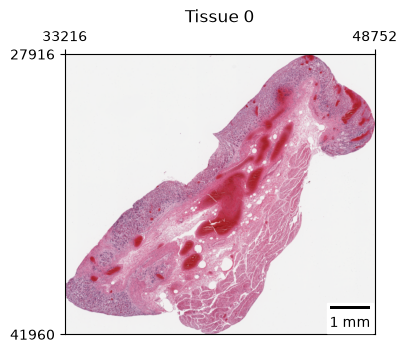

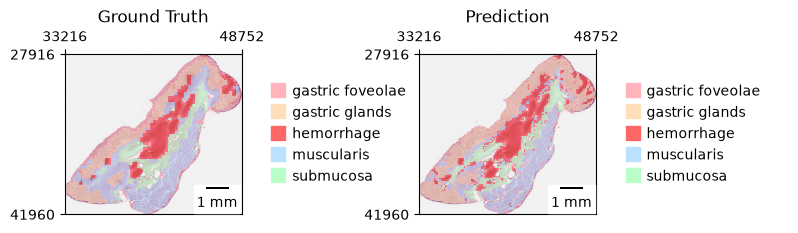

In [14]:
import lazyslide as zs

opts = dict(
    tissue_id=0,
    show_contours=False,
    mark_origin=False,
)
zs.pl.tissue(test1, **opts)

zs.pl.tiles(
    test1,
    color=["domain", "infer_domain"],
    alpha=0.6,
    palette={
        "gastric foveolae": "#FFB3BA",  # soft pink
        "gastric glands": "#FFDFBA",  # peach
        "hemorrhage": "#FF6666",  # red
        "muscularis": "#BAE1FF",  # light blue
        "submucosa": "#BAFFC9",  # light green
    },
    title=[
        "Ground Truth",
        "Prediction",
    ],
    wspace=1,
    **opts,
)

## Conclusion

Congratulations! You've successfully built a model that can perform tile prediction to approximate segmentation.

The final step is to save the model for future use. We recommend saving the model as a JIT scripted model when possible, as this allows the model to run in any Python environment or PyTorch runtime.

In [15]:
scripted_model = torch.jit.script(model)
torch.jit.save(scripted_model, "tile_model.pt")

# To load the model back
scripted_model = torch.jit.load("tile_model.pt")